# Fair-RAG Reproduction Notebook

This notebook reproduces the **Towards Fair RAG** experiment pipeline in this repository:
1. Prepare data and folders
2. Precompute deterministic retrieval
3. Build oracle retrieval inputs (delta files)
4. Run stochastic retrieval + generation + measurement
5. Normalize EU and Expected Exposure metrics (EE-D, EE-R, EE-L)
6. Aggregate and plot results (including Figure 4: EE-R vs EE-D)

> Default settings are CPU-safe and start with a smaller run. Switch to full settings in the parameters cell for paper-scale runs.


In [15]:
from pathlib import Path
import os
import sys
import json
import zipfile
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import warnings

# Suppress transformers pipeline warnings
warnings.filterwarnings('ignore', category=UserWarning, module='transformers')
warnings.filterwarnings('ignore', message='.*pipelines sequentially on GPU.*')

REPO_ROOT = Path.cwd()
print('Repo root:', REPO_ROOT)
assert (REPO_ROOT / 'experiment.py').exists(), 'Run this notebook from the repository root.'

# Show model cache location
HF_CACHE = Path.home() / '.cache' / 'huggingface' / 'hub'
print(f'\nModel cache directory: {HF_CACHE}')
print(f'Models will be downloaded here on first use (~1-15GB depending on model size)')

Repo root: /home/student/Fair-RAG

Model cache directory: /home/student/.cache/huggingface/hub
Models will be downloaded here on first use (~1-15GB depending on model size)


## Model Download & Caching

When you first run experiments with a language model (e.g., `flanT5Small`), the model (~1-2GB) is automatically downloaded from Hugging Face Hub and cached locally at:

```
~/.cache/huggingface/hub/
```

Subsequent runs use the cached copy—**no re-downloading needed**. 

### What happens during a run:
- **Cell 4**: Extracts and validates datasets (~2-3 min)
- **Cell 5**: Builds oracle inputs from relevance mappings (~1 min)
- **Cell 6**: Precomputes BM25 retrieval (~5-10 min per LAMP task)
- **Cell 7**: Runs stochastic experiments with LLM generation (longest step, ~10-30 min per run depending on model size)
- **Cell 8**: Normalizes and aggregates results (~1-2 min)

**Live output below shows exactly what's happening at each step.**

In [ ]:
# ===== Helper function to run commands with live output =====
def run_cmd(cmd, description=""):
    """Run a command and stream output in real-time."""
    if description:
        print(f"\n{'='*60}")
        print(f"[{datetime.now().strftime('%H:%M:%S')}] {description}")
        print(f"{'='*60}")
    print(f"Command: {' '.join(cmd)}\n")
    
    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        cwd=REPO_ROOT,
        bufsize=1
    )
    
    for line in proc.stdout:
        print(line.rstrip())
    
    returncode = proc.wait()
    if returncode != 0:
        raise RuntimeError(f"Command failed with code {returncode}")
    print()

def load_and_display_stats(lamp_num, retriever, alpha, run_id):
    """Load normalized results and display stats for a completed experiment."""
    # Try timestamped location first, then fall back to default
    fp_timestamped = REPO_ROOT / 'experiment_results' / run_id / GENERATOR_NAME / f'lamp{lamp_num}' / retriever / f'alpha_{alpha}_normalized.json'
    fp_default = REPO_ROOT / 'experiment_results' / GENERATOR_NAME / f'lamp{lamp_num}' / retriever / f'alpha_{alpha}_normalized.json'
    
    fp = fp_timestamped if fp_timestamped.exists() else fp_default
    
    if not fp.exists():
        return None
    
    try:
        with open(fp, 'r', encoding='utf-8') as f:
            d = json.load(f)
        
        first_qid = next(iter(d.keys()))
        metric_name = next(iter(d[first_qid]['EU'].keys()))
        
        # Extract all three EE metrics
        ee_disparity = [v['EE']['disparity'] for v in d.values()]
        ee_relevance = [v['EE']['relevance'] for v in d.values()]
        ee_difference = [v['EE']['difference'] for v in d.values()]
        eu_vals = [v['EU'][metric_name] for v in d.values()]
        
        ee_d_mean = float(pd.Series(ee_disparity).mean())
        ee_d_std = float(pd.Series(ee_disparity).std())
        ee_r_mean = float(pd.Series(ee_relevance).mean())
        ee_r_std = float(pd.Series(ee_relevance).std())
        ee_l_mean = float(pd.Series(ee_difference).mean())
        ee_l_std = float(pd.Series(ee_difference).std())
        eu_mean = float(pd.Series(eu_vals).mean())
        eu_std = float(pd.Series(eu_vals).std())
        
        print(f"  📊 Stats for LaMP{lamp_num} | {retriever} | alpha={alpha}:")
        print(f"      EE-D (Disparity):  {ee_d_mean:.4f} ± {ee_d_std:.4f}")
        print(f"      EE-R (Relevance):  {ee_r_mean:.4f} ± {ee_r_std:.4f}")
        print(f"      EE-L (Difference): {ee_l_mean:.4f} ± {ee_l_std:.4f}")
        print(f"      Normalized EU:     {eu_mean:.4f} ± {eu_std:.4f}")
        print(f"      Queries processed: {len(d)}")
        
        return {
            'lamp_num': lamp_num,
            'retriever': retriever,
            'alpha': alpha,
            'metric': metric_name,
            'EE_D_mean': ee_d_mean,
            'EE_D_std': ee_d_std,
            'EE_R_mean': ee_r_mean,
            'EE_R_std': ee_r_std,
            'EE_L_mean': ee_l_mean,
            'EE_L_std': ee_l_std,
            'EU_mean': eu_mean,
            'EU_std': eu_std,
            'query_count': len(d)
        }
    except Exception as e:
        print(f"  ⚠️ Could not load stats: {str(e)}")
        return None

# ===== Parameters =====
GENERATOR_NAME = 'flanT5Small'  # flanT5Small | flanT5Base | flanT5XXL
LAMP_NUMS = [4]                 # use [1,2,3,4,5,6,7] for full sweep
RETRIEVERS = ['bm25']           # CPU-safe: bm25; GPU-heavy: contriever, splade
ALPHAS = [1, 2, 4, 8]
K = 5
N_SAMPLES = 8                   # number of stochastic samples per query; paper default is 100
MAX_QUERIES = 30                # limit queries per config; None to process all
QUERY_BATCH_SIZE = 10           # report stats every N queries
REMOVE_TEMP_FILES = True
RUN_EXPERIMENTS = True

# Generate timestamped run ID to avoid overwriting experiments
RUN_ID = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
RUN_DIR = REPO_ROOT / 'experiment_results' / RUN_ID

# For paper-scale reproduction (requires significant compute), set:
# LAMP_NUMS = [1,2,3,4,5,6,7]
# RETRIEVERS = ['bm25', 'contriever', 'splade']
# N_SAMPLES = 100
# MAX_QUERIES = None (or remove the limit)

print(f"Configuration:")
print(f"  Generator: {GENERATOR_NAME}")
print(f"  LaMP tasks: {LAMP_NUMS}")
print(f"  Retrievers: {RETRIEVERS}")
print(f"  Alphas: {ALPHAS}")
print(f"  Samples per query: {N_SAMPLES}")
print(f"  Queries per config: {MAX_QUERIES if MAX_QUERIES else 'all'}")
print(f"  Stats batch size: {QUERY_BATCH_SIZE}")
print(f"  Run ID: {RUN_ID}")
print(f"  Results will be saved to: {RUN_DIR}")
print(f"  Total experiment combinations: {len(LAMP_NUMS) * len(RETRIEVERS) * len(ALPHAS)}")


Configuration:
  Generator: flanT5Small
  LaMP tasks: [4]
  Retrievers: ['bm25']
  Alphas: [1, 2, 4, 8]
  Samples per query: 8
  Queries per config: 30
  Stats batch size: 10
  Run ID: 2026-03-05_21-02-20
  Results will be saved to: /home/student/Fair-RAG/experiment_results/2026-03-05_21-02-20
  Total experiment combinations: 4


In [17]:
# ===== Setup: unzip provided utility datasets + create temp dirs =====
data_dir = REPO_ROOT / 'data'
for zfp in sorted(data_dir.glob('lamp_utility_labels_*.zip')):
    with zipfile.ZipFile(zfp, 'r') as zf:
        zf.extractall(data_dir)

nested = data_dir / 'data'
if nested.exists():
    for sub in nested.iterdir():
        target = data_dir / sub.name
        if not target.exists():
            sub.rename(target)
    try:
        nested.rmdir()
    except OSError:
        pass

(REPO_ROOT / 'trec_top_files').mkdir(exist_ok=True)
(REPO_ROOT / 'trec_rel_files').mkdir(exist_ok=True)
print('Data and temp directories are ready.')

Data and temp directories are ready.


In [18]:
# ===== Build delta files needed by retrieval/gold_retriever.py =====
cmd = [
    sys.executable,
    str(REPO_ROOT / 'utility_labels' / 'bootstrap_eval_results_from_relevance.py'),
    '--generator_name', GENERATOR_NAME,
    '--lamp_nums', *[str(x) for x in LAMP_NUMS],
]
run_cmd(cmd, "Building oracle retrieval delta files from relevance mappings")


[21:02:30] Building oracle retrieval delta files from relevance mappings
Command: /anaconda/envs/azureml_py310_sdkv2/bin/python /home/student/Fair-RAG/utility_labels/bootstrap_eval_results_from_relevance.py --generator_name flanT5Small --lamp_nums 4



Wrote: /home/student/Fair-RAG/utility_labels/eval_results/flanT5Small/4_delta.tsv



In [19]:
# ===== Precompute deterministic retrieval and oracle retrieval =====
for lamp_num in LAMP_NUMS:
    for retriever in RETRIEVERS:
        cmd = [
            sys.executable,
            str(REPO_ROOT / 'retrieval' / 'rank_profiles.py'),
            '--ranker', retriever,
            '--generator_name', GENERATOR_NAME,
            '--lamp_num', str(lamp_num),
        ]
        run_cmd(cmd, f"Precomputing {retriever.upper()} retrieval for LaMP {lamp_num}")

    cmd = [
        sys.executable,
        str(REPO_ROOT / 'retrieval' / 'gold_retriever.py'),
        '--generator_name', GENERATOR_NAME,
        '--lamp_num', str(lamp_num),
    ]
    run_cmd(cmd, f"Building oracle (gold) retrieval for LaMP {lamp_num}")


[21:02:33] Precomputing BM25 retrieval for LaMP 4
Command: /anaconda/envs/azureml_py310_sdkv2/bin/python /home/student/Fair-RAG/retrieval/rank_profiles.py --ranker bm25 --generator_name flanT5Small --lamp_num 4


100%|██████████| 833/833 [00:04<00:00, 177.46it/s]


[21:02:41] Building oracle (gold) retrieval for LaMP 4
Command: /anaconda/envs/azureml_py310_sdkv2/bin/python /home/student/Fair-RAG/retrieval/gold_retriever.py --generator_name flanT5Small --lamp_num 4




In [22]:
# ===== Main experiments + normalization =====
if RUN_EXPERIMENTS:
    import shutil
    
    # Ensure timestamped directory exists
    RUN_DIR.mkdir(parents=True, exist_ok=True)
    
    retrievers_to_run = list(dict.fromkeys(RETRIEVERS + ['gold']))
    total_runs = sum(len(LAMP_NUMS) * (1 if r == 'gold' else len(ALPHAS)) for r in retrievers_to_run)
    run_count = 0

    for lamp_num in LAMP_NUMS:
        for retriever in retrievers_to_run:
            alpha_list = [8] if retriever == 'gold' else ALPHAS
            for alpha in alpha_list:
                run_count += 1
                status = f"[{run_count}/{total_runs}]"
                
                cmd = [
                    sys.executable, str(REPO_ROOT / 'experiment.py'),
                    '--retriever_name', retriever,
                    '--generator_name', GENERATOR_NAME,
                    '--lamp_num', str(lamp_num),
                    '--alpha', str(alpha),
                    '--k', str(K),
                    '--n_samples', str(N_SAMPLES),
                    '--max_queries', str(MAX_QUERIES) if MAX_QUERIES else 'None',
                    '--query_batch_size', str(QUERY_BATCH_SIZE),
                    '--run_id', RUN_ID,
                ]
                if REMOVE_TEMP_FILES:
                    cmd.append('--remove_temp_files')
                
                run_cmd(cmd, f"{status} Running experiment: LaMP{lamp_num} | {retriever} | alpha={alpha}")
                
                # Copy experiment results to timestamped directory
                src_dir = REPO_ROOT / 'experiment_results' / GENERATOR_NAME / f'lamp{lamp_num}' / retriever
                dst_dir = RUN_DIR / GENERATOR_NAME / f'lamp{lamp_num}' / retriever
                if src_dir.exists():
                    dst_dir.mkdir(parents=True, exist_ok=True)
                    for file in src_dir.glob(f'alpha_{alpha}*'):
                        shutil.copy2(file, dst_dir / file.name)

        for retriever in RETRIEVERS:
            for alpha in ALPHAS:
                cmd = [
                    sys.executable, str(REPO_ROOT / 'normalize_eu.py'),
                    '--retriever_name', retriever,
                    '--generator_name', GENERATOR_NAME,
                    '--lamp_num', str(lamp_num),
                    '--alpha', str(alpha),
                    '--run_id', RUN_ID,
                ]
                run_cmd(cmd, f"Normalizing results: LaMP{lamp_num} | {retriever} | alpha={alpha}")
                
                # Copy normalized results to timestamped directory
                src_dir = REPO_ROOT / 'experiment_results' / GENERATOR_NAME / f'lamp{lamp_num}' / retriever
                dst_dir = RUN_DIR / GENERATOR_NAME / f'lamp{lamp_num}' / retriever
                if src_dir.exists():
                    dst_dir.mkdir(parents=True, exist_ok=True)
                    for file in src_dir.glob(f'alpha_{alpha}_normalized*'):
                        shutil.copy2(file, dst_dir / file.name)
                
                # Display stats for this completed experiment
                load_and_display_stats(lamp_num, retriever, alpha, RUN_ID)
                
    print("\n" + "="*60)
    print(f"✓ All experiments completed!")
    print(f"📁 Results saved to: {RUN_DIR}")
    print("="*60)


[21:07:20] [1/5] Running experiment: LaMP4 | bm25 | alpha=1
Command: /anaconda/envs/azureml_py310_sdkv2/bin/python /home/student/Fair-RAG/experiment.py --retriever_name bm25 --generator_name flanT5Small --lamp_num 4 --alpha 1 --k 5 --n_samples 8 --max_queries 30 --query_batch_size 10 --run_id 2026-03-05_21-02-20 --remove_temp_files



/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Processing 30 queries...
  Progress: 10/30 queries completed
  Progress: 20/30 queries completed
  Progress: 30/30 queries completed

Completed 30 queries.
Summary - EE Difference: mean=0.3246, std=0.1130
Summary - Expected Utility: mean=0.0218, std=0.0212


[21:14:11] [2/5] Running experiment: LaMP4 | bm25 | alpha=2
Command: /anaconda/envs/azureml_py310_sdkv2/bin/python /home/student/Fair-RAG/experiment.py --retriever_name bm25 --generator_name flanT5Small --lamp_num 4 --alpha 2 --k 5 --n_samples 8 --max_queries 30 --query_batch_size 10 --run_id 2026-03-05_21-02-20 --remove_temp_files

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/huggingface_hub/file_download.py:94


Aggregating results from 1 LaMP task(s), 1 retriever(s), 4 alpha value(s)...
Using results from: /home/student/Fair-RAG/experiment_results/2026-03-05_21-02-20

Summary of Results:
 lamp_num retriever  alpha  metric  EE_difference_mean  EE_difference_std  EU_mean   EU_std
        4      bm25      1 rouge-l            0.324637           0.114956 0.166582 0.144297
        4      bm25      2 rouge-l            0.358599           0.107126 0.181150 0.125034
        4      bm25      4 rouge-l            0.705264           0.129518 0.161536 0.165380
        4      bm25      8 rouge-l            0.902043           0.091364 0.162595 0.215556



,lamp_num,retriever,alpha,metric,EE_difference_mean,EE_difference_std,EU_mean,EU_std
0,4,bm25,1,rouge-l,0.324637,0.114956,0.166582,0.144297
1,4,bm25,2,rouge-l,0.358599,0.107126,0.181150,0.125034
2,4,bm25,4,rouge-l,0.705264,0.129518,0.161536,0.165380
3,4,bm25,8,rouge-l,0.902043,0.091364,0.162595,0.215556


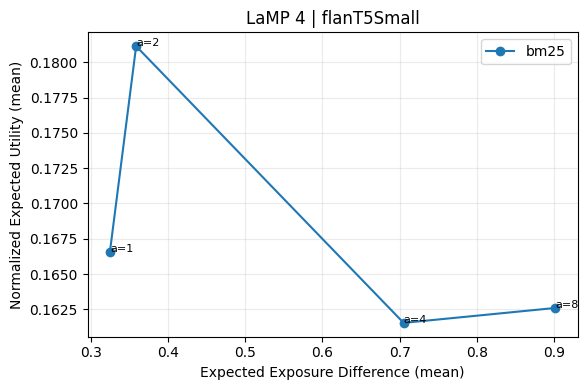

✓ Saved summary (timestamped): experiment_results/2026-03-05_21-02-20/flanT5Small/summary_metrics.csv
✓ Saved summary (default): experiment_results/flanT5Small/summary_metrics.csv

Model cache used: 0.6 GB at /home/student/.cache/huggingface/hub

📋 Experiment Log Files
Experiment log: experiment_results/flanT5Small/lamp4/bm25/alpha_1.log
Log files contain configuration, progress, and result summaries for each run.


In [ ]:
# ===== Aggregate and plot =====
print(f"\nAggregating results from {len(LAMP_NUMS)} LaMP task(s), {len(RETRIEVERS)} retriever(s), {len(ALPHAS)} alpha value(s)...")
print(f"Using results from: {RUN_DIR}\n")

rows = []
for lamp_num in LAMP_NUMS:
    for retriever in RETRIEVERS:
        for alpha in ALPHAS:
            # Try timestamped location first, then fall back to default
            fp_timestamped = RUN_DIR / GENERATOR_NAME / f'lamp{lamp_num}' / retriever / f'alpha_{alpha}_normalized.json'
            fp_default = REPO_ROOT / 'experiment_results' / GENERATOR_NAME / f'lamp{lamp_num}' / retriever / f'alpha_{alpha}_normalized.json'
            
            fp = fp_timestamped if fp_timestamped.exists() else fp_default
            
            if not fp.exists():
                print(f"Skipping missing: {fp.name}")
                continue
            with open(fp, 'r', encoding='utf-8') as f:
                d = json.load(f)

            first_qid = next(iter(d.keys()))
            metric_name = next(iter(d[first_qid]['EU'].keys()))
            
            # Extract all three EE metrics
            ee_disparity = [v['EE']['disparity'] for v in d.values()]
            ee_relevance = [v['EE']['relevance'] for v in d.values()]
            ee_difference = [v['EE']['difference'] for v in d.values()]
            eu_vals = [v['EU'][metric_name] for v in d.values()]

            rows.append({
                'lamp_num': lamp_num,
                'retriever': retriever,
                'alpha': alpha,
                'metric': metric_name,
                'EE_D_mean': float(pd.Series(ee_disparity).mean()),
                'EE_D_std': float(pd.Series(ee_disparity).std()),
                'EE_R_mean': float(pd.Series(ee_relevance).mean()),
                'EE_R_std': float(pd.Series(ee_relevance).std()),
                'EE_L_mean': float(pd.Series(ee_difference).mean()),
                'EE_L_std': float(pd.Series(ee_difference).std()),
                'EU_mean': float(pd.Series(eu_vals).mean()),
                'EU_std': float(pd.Series(eu_vals).std()),
            })

if rows:
    summary = pd.DataFrame(rows).sort_values(['lamp_num', 'retriever', 'alpha'])
    print("Summary of Results:")
    print(summary.to_string(index=False))
    print()
    
    display(summary)

    if not summary.empty:
        for lamp_num, lamp_df in summary.groupby('lamp_num'):
            # Figure 4: EE-R vs EE-D (Fairness-Utility Tradeoff)
            plt.figure(figsize=(6, 4))
            for retriever, retr_df in lamp_df.groupby('retriever'):
                retr_df = retr_df.sort_values('alpha')
                plt.plot(retr_df['EE_D_mean'], retr_df['EE_R_mean'], marker='o', label=retriever, linewidth=2, markersize=8)
                for _, r in retr_df.iterrows():
                    plt.annotate(f"α={int(r['alpha'])}", (r['EE_D_mean'], r['EE_R_mean']), 
                                fontsize=8, xytext=(5, 5), textcoords='offset points')

            plt.title(f'Figure 4: Fairness-Utility Tradeoff | LaMP {lamp_num} | {GENERATOR_NAME}')
            plt.xlabel('EE-D: Expected Exposure Disparity (mean)')
            plt.ylabel('EE-R: Expected Exposure Relevance (mean)')
            plt.grid(True, alpha=0.25)
            plt.legend()
            plt.tight_layout()
            plt.show()
            
            # Additional plot: EE-L vs EU (Distance vs Utility)
            plt.figure(figsize=(6, 4))
            for retriever, retr_df in lamp_df.groupby('retriever'):
                retr_df = retr_df.sort_values('alpha')
                plt.plot(retr_df['EE_L_mean'], retr_df['EU_mean'], marker='s', label=retriever, linewidth=2, markersize=8)
                for _, r in retr_df.iterrows():
                    plt.annotate(f"α={int(r['alpha'])}", (r['EE_L_mean'], r['EU_mean']), 
                                fontsize=8, xytext=(5, 5), textcoords='offset points')

            plt.title(f'Distance vs Utility | LaMP {lamp_num} | {GENERATOR_NAME}')
            plt.xlabel('EE-L: Expected Exposure Distance (L2 from target)')
            plt.ylabel('Normalized Expected Utility (mean)')
            plt.grid(True, alpha=0.25)
            plt.legend()
            plt.tight_layout()
            plt.show()

        # Save summary to both timestamped and default locations
        out_csv_timestamped = RUN_DIR / GENERATOR_NAME / 'summary_metrics.csv'
        out_csv_default = REPO_ROOT / 'experiment_results' / GENERATOR_NAME / 'summary_metrics.csv'
        out_csv_timestamped.parent.mkdir(parents=True, exist_ok=True)
        out_csv_default.parent.mkdir(parents=True, exist_ok=True)
        
        summary.to_csv(out_csv_timestamped, index=False)
        summary.to_csv(out_csv_default, index=False)
        
        print(f'✓ Saved summary (timestamped): {out_csv_timestamped.relative_to(REPO_ROOT)}')
        print(f'✓ Saved summary (default): {out_csv_default.relative_to(REPO_ROOT)}')
        
        # Show cached models info
        hf_cache = Path.home() / '.cache' / 'huggingface' / 'hub'
        if hf_cache.exists():
            cache_size_gb = sum(f.stat().st_size for f in hf_cache.rglob('*') if f.is_file()) / (1024**3)
            print(f'\nModel cache used: {cache_size_gb:.1f} GB at {hf_cache}')
        
        # Show log files info
        print(f'\n' + '='*60)
        print(f'📋 Experiment Log Files')
        print(f'='*60)
        logs_found = False
        for lamp_num in LAMP_NUMS:
            for retriever in RETRIEVERS:
                for alpha in ALPHAS:
                    log_dir = REPO_ROOT / 'experiment_results' / GENERATOR_NAME / f'lamp{lamp_num}' / retriever
                    exp_log = log_dir / f'alpha_{alpha}.log'
                    norm_log = log_dir / f'alpha_{alpha}_normalize.log'
                    
                    if exp_log.exists():
                        print(f'Experiment log: {exp_log.relative_to(REPO_ROOT)}')
                        logs_found = True
                    if norm_log.exists():
                        print(f'Normalization log: {norm_log.relative_to(REPO_ROOT)}')
                        logs_found = True
        
        if logs_found:
            print(f'Log files contain configuration, progress, and result summaries for each run.')
        print(f'='*60)
        
        # Print metric definitions
        print(f'\n' + '='*60)
        print(f'📖 Expected Exposure Metric Definitions')
        print(f'='*60)
        print(f'EE-D (Disparity):  L2 norm of exposure distribution (concentration)')
        print(f'EE-R (Relevance):  Dot product with target exposure (relevant item exposure)')
        print(f'EE-L (Difference): L2 distance from target exposure (overall distance)')
        print(f'='*60)
else:
    print("No results found. Run cells 4-7 first to generate experiment outputs.")


In [ ]:
## Expected Exposure Metrics Explained

The experiment pipeline computes **three separate Expected Exposure (EE) metrics** for each query:

### 📊 EE-D (Disparity)
- **Definition**: L2 norm of the exposure distribution
- **Measures**: How concentrated vs. spread out the exposure is across items
- **Range**: Higher values = more concentrated (less fair)

### 📊 EE-R (Relevance)  
- **Definition**: Dot product of actual exposure with target exposure
- **Measures**: How well relevant items are being exposed
- **Range**: Higher values = better exposure of relevant items

### 📊 EE-L (Difference)
- **Definition**: L2 distance between actual and target exposure distributions
- **Measures**: Overall deviation from ideal fair exposure
- **Range**: Lower values = closer to target (more fair)

**Figure 4 in the paper** plots **EE-R vs EE-D** to show the classic fairness-utility tradeoff: as you increase fairness (lower disparity), you may decrease utility (lower relevance exposure).
